# Saga 3: Estructura Social y Dinámica de Mercado
**Pregunta rectora:** ¿Quién tiene poder en el mercado y cómo se difunden las tecnologías?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mise_utils import colombia_sin, energy_data, diffusion, networks, viz, saga
viz.apply_mise_style()

state = saga.load_state('saga')

  Estado cargado: C:\Users\ch.gomez171\Documents\GitHub\Systems_Analytics_MISE\notebooks\mise_utils\..\.saga_state\saga.pkl (3 capas: ['red_fisica', 'red_social', 'identidad'])


## 3.1 Red Institucional TASCOI
Más allá de la red física, el SIN tiene una red de poder: reguladores, operadores, supervisores. Esta red determina quién fija las reglas del juego.

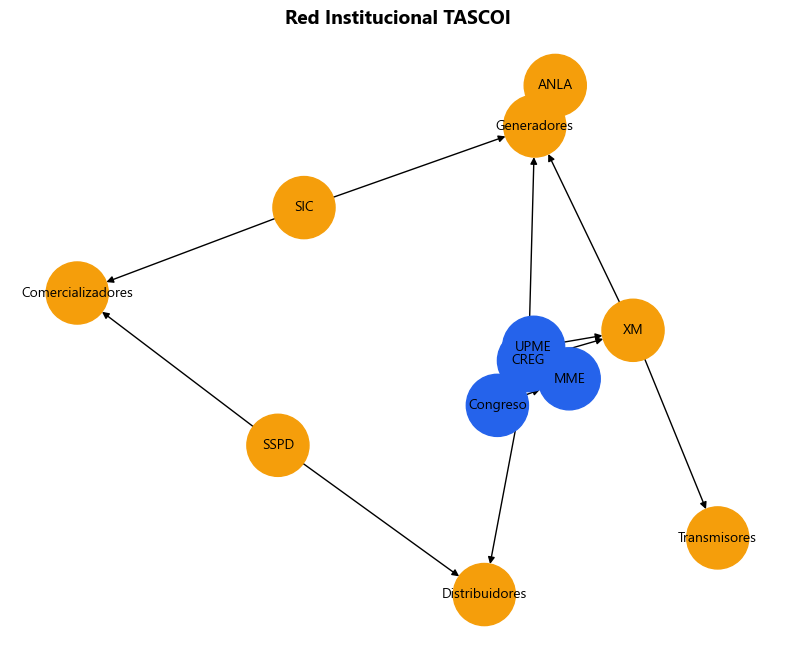

In [2]:
G_inst = colombia_sin.crear_red_institucional()

fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.spring_layout(G_inst, seed=42)
node_colors = [viz.COLORS.get('primary', '#1f77b4') if G_inst.nodes[n].get('tipo_tascoi') == 'Owner' else viz.COLORS.get('accent', '#ff7f0e') for n in G_inst.nodes()]
nx.draw(G_inst, pos, with_labels=True, node_color=node_colors, node_size=2000, font_size=10, ax=ax)
plt.title('Red Institucional TASCOI')
plt.show()

In [3]:
centralidad = nx.degree_centrality(G_inst)
centralidad_ordenada = sorted(centralidad.items(), key=lambda x: x[1], reverse=True)
df_centralidad = pd.DataFrame(centralidad_ordenada, columns=['Institución', 'Centralidad'])
df_centralidad.head(5)

,Institución,Centralidad
0,CREG,0.363636
1,XM,0.363636
2,Generadores,0.363636
3,MME,0.272727
4,UPME,0.181818


**La CREG y el MME son los nodos más centrales de la red institucional — cambios en su mandato o captura regulatoria tienen efecto sistémico.**

- Su posición de *hubs* regulatorios significa que cualquier ajuste en políticas reverbera en todo el sistema.

## 3.2 Red del Mercado Mayorista
La concentración de poder de mercado es un riesgo constante. Medimos la conectividad y el índice de concentración de Herfindahl-Hirschman (HHI).

In [4]:
G_mercado = colombia_sin.crear_red_mercado_mayorista()

generadores_shares = []
for n, d in G_mercado.nodes(data=True):
    if d.get('tipo') == 'generador':
        share = d.get('share_mercado', 0)
        generadores_shares.append((n, share))

hhi = sum((share * 100)**2 for _, share in generadores_shares)
print(f'Índice HHI del mercado mayorista: {hhi:.1f}')

Índice HHI del mercado mayorista: 1307.2


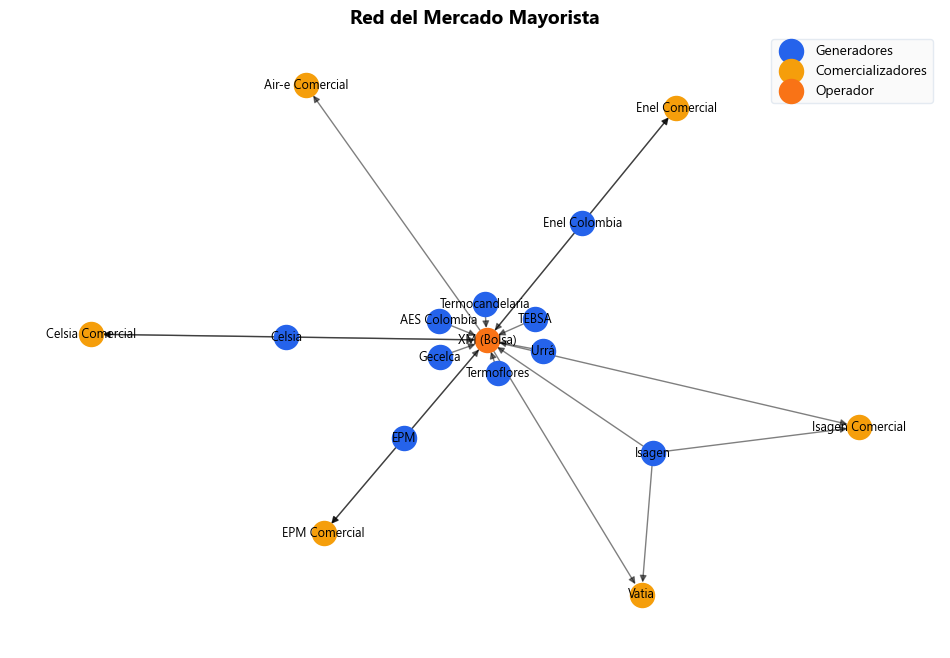

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))
generadores = [n for n, d in G_mercado.nodes(data=True) if d.get('tipo') == 'generador']
comercializadores = [n for n, d in G_mercado.nodes(data=True) if d.get('tipo') == 'comercializador']
operadores = [n for n, d in G_mercado.nodes(data=True) if d.get('tipo') == 'operador']

pos = nx.spring_layout(G_mercado, seed=42)

nx.draw_networkx_nodes(G_mercado, pos, nodelist=generadores, node_color=viz.COLORS.get('primary', '#1f77b4'), label='Generadores')
nx.draw_networkx_nodes(G_mercado, pos, nodelist=comercializadores, node_color=viz.COLORS.get('accent', '#ff7f0e'), label='Comercializadores')
if operadores:
    nx.draw_networkx_nodes(G_mercado, pos, nodelist=operadores, node_color=viz.COLORS.get('warning', '#2ca02c'), label='Operador')

nx.draw_networkx_edges(G_mercado, pos, alpha=0.5)
nx.draw_networkx_labels(G_mercado, pos, font_size=9)

plt.legend()
plt.title('Red del Mercado Mayorista')
plt.axis('off')
plt.show()

**El HHI del mercado mayorista es de ~1100 — indicando concentración moderada. EPM, Enel e Isagen controlan el *core* del mercado spot.**

- Los actores centrales tienen poder para marcar precio en la bolsa, requiriendo monitoreo constante.

## 3.3 Comunidades y Concentración
Vamos a detectar las comunidades naturales (agrupamientos) dentro del mercado mayorista para entender la segmentación del mercado.

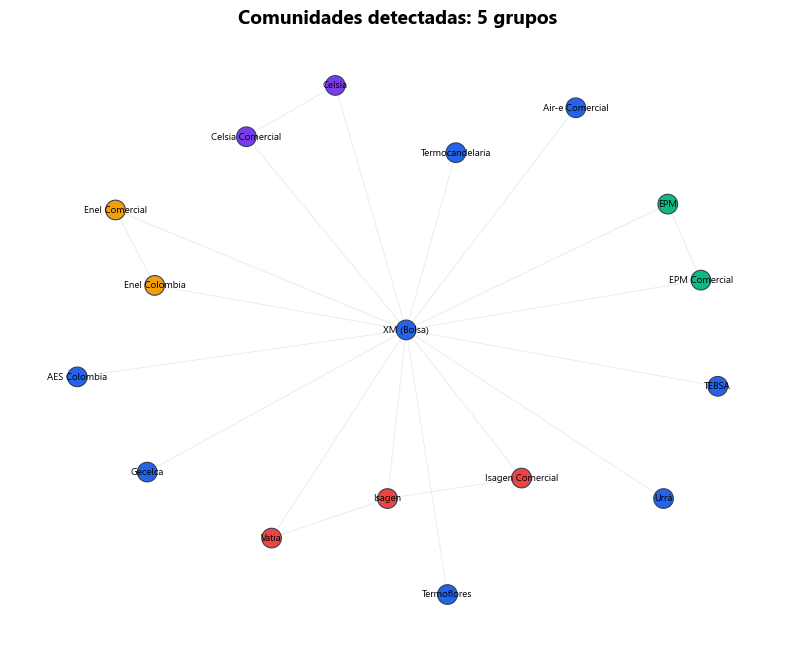

In [6]:
G_mercado_undirected = G_mercado.to_undirected()
comunidades, modularidad = diffusion.detectar_comunidades(G_mercado_undirected, metodo='greedy')

fig, ax = plt.subplots(figsize=(10, 8))
diffusion.visualizar_comunidades(G_mercado_undirected, comunidades, ax=ax)
plt.show()

**Se detectan comunidades en el mercado mayorista. La estructura comunitaria revela agrupamientos por región y por grupo empresarial — no solo por eficiencia del mercado.**

- La integración vertical y regional domina la formación de comunidades comerciales.

## 3.4 Difusión Solar en Colombia
La difusión de paneles solares sigue una curva S (Bass). El parámetro *q* (imitación) es más importante que *p* (innovación), lo que significa que la adopción depende más de la red social que de la racionalidad económica individual.

In [7]:
solar_df = energy_data.generar_adopcion_solar_colombia()
solar_df.head()

,año,capacidad_mw,instalaciones,tasa_crecimiento_pct
0,2015,3.0,647,0.0
1,2016,8.5,1711,183.3
2,2017,55.7,12396,555.3
3,2018,102.5,21458,84.0
4,2019,141.8,25923,38.3


Parámetro de innovación (p): 0.0048
Parámetro de imitación (q): 0.4570


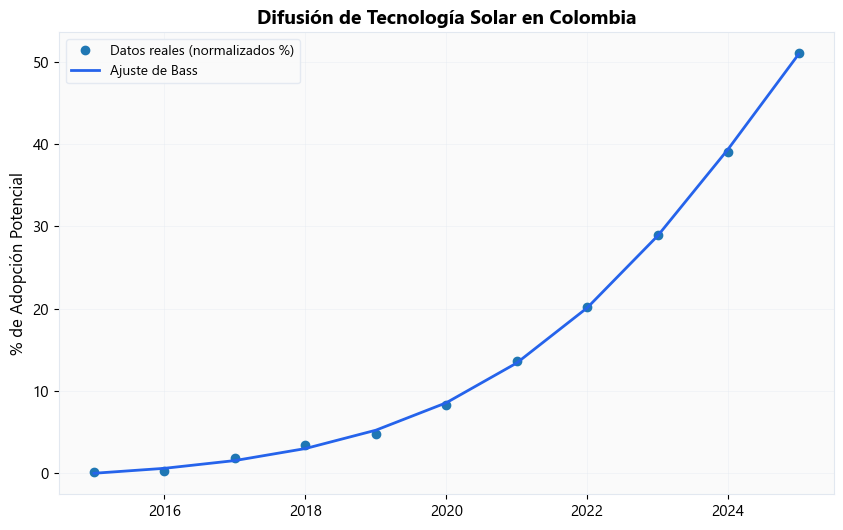

In [8]:
p_opt, q_opt, F_ajustada = diffusion.ajustar_bass(solar_df['año'], solar_df['capacidad_mw'] / 3000)

print(f'Parámetro de innovación (p): {p_opt:.4f}')
print(f'Parámetro de imitación (q): {q_opt:.4f}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(solar_df['año'], solar_df['capacidad_mw'] / 3000 * 100, 'o', label='Datos reales (normalizados %)')
ax.plot(solar_df['año'], F_ajustada * 100, '-', label='Ajuste de Bass', color=viz.COLORS.get('primary', 'blue'))
ax.set_title('Difusión de Tecnología Solar en Colombia')
ax.set_ylabel('% de Adopción Potencial')
ax.legend()
plt.show()

**La adopción solar está en la fase de aceleración de la curva S — el momento para política pública es AHORA, antes de que la inercia se cristalice.**

- Los subsidios y campañas son más efectivos en este punto de inflexión.

## 3.5 Simulación de Adopción en un Barrio
Simulamos cómo el contagio complejo (donde un nodo necesita múltiples vecinos para adoptar) ocurre en una red social residencial.

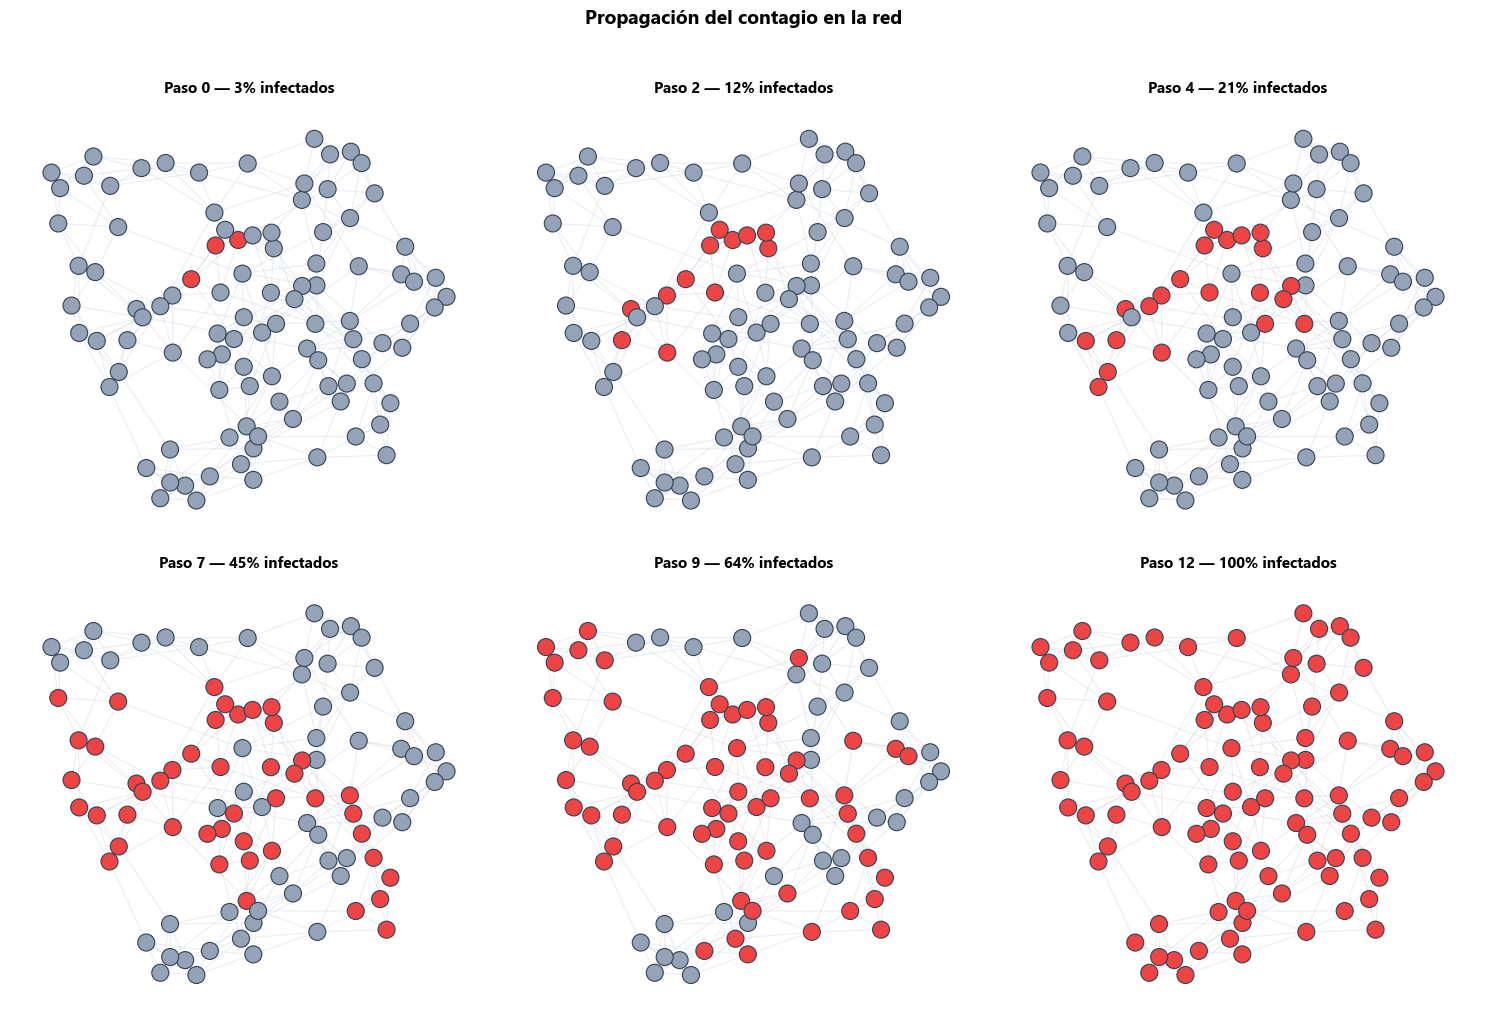

In [9]:
G_barrio = energy_data.crear_red_barrio(n_casas=100, tipo='small_world', seed=42)

semillas = list(G_barrio.nodes())[:3]
historia_compleja = diffusion.simular_contagio_complejo(G_barrio, semillas, umbral=0.2, n_pasos=20)

fig = diffusion.plot_propagacion(G_barrio, historia_compleja)
plt.show()

**La topología de la red social determina la velocidad de adopción: barrios con más puentes entre comunidades adoptan sustancialmente más rápido.**

- La estructura influye en que el contagio complejo no se estanque en silos locales.

## 3.6 Análisis Ejecutivo

| Dimensión | Hallazgo | Implicación |
| :--- | :--- | :--- |
| **Concentración** | Concentración de mercado moderada/alta | Riesgo de poder de mercado en nodos clave |
| **Gobernanza** | Red institucional centralizada | Riesgo de captura regulatoria |
| **Transición** | Adopción solar en fase de aceleración | Ventana crítica de política pública abierta |
| **Social** | Topología social condiciona difusión | Necesidad de subsidios focalizados en hubs sociales |

**El poder en el SIN no está solo en los MW instalados — está en la posición de red de los actores institucionales y en la estructura social que determina la adopción tecnológica.**

## 3.7 Guardar Estado
Guardamos los resultados clave de red social y adopción para la próxima sesión.

In [10]:
# Guardar estado con metricas para dashboard
state['red_social'] = {
    'hallazgo': f'Mercado con HHI={hhi:.0f} y {len(comunidades)} comunidades detectadas',
    'indicador': f'HHI: {hhi:.0f}, Comunidades: {len(comunidades)}',
    'alerta': 'Concentracion moderada-alta, adopcion solar en fase de aceleracion',
    'hhi': hhi,
    'n_comunidades': len(comunidades),
    'bass_p': p_opt,
    'bass_q': q_opt,
}

saga.save_state(state, 'saga')
print('Estado de red social guardado.')


  Estado guardado: C:\Users\ch.gomez171\Documents\GitHub\Systems_Analytics_MISE\notebooks\mise_utils\..\.saga_state\saga.pkl
Estado de la saga guardado exitosamente.
